# Shopper Spectrum — Customer EDA & Data Preparation


In [1]:
#  Library Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

BASE_DIR = Path('.').resolve()
DATA_DIR = BASE_DIR / 'data'


## Step 1 — Load Raw Dataset


In [ ]:
df_raw = pd.read_csv(r"D:\AI_System\files\online_retail.csv") #replace it with the link of the dataset
print(f'Shape  : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'Memory : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df_raw.head()


Shape  : 541,909 rows x 8 columns
Memory : 183.7 MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


## Step 2 — Initial Data Quality Assessment


In [3]:
df_raw.info()
print('\n--- Missing Values ---')
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({'Missing': missing, 'Percent': missing_pct})


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

--- Missing Values ---


,Missing,Percent
InvoiceNo,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,135080,24.93
Country,0,0.00


In [4]:
df_raw.describe()


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [5]:
dup_count = df_raw.duplicated().sum()
print(f'Total duplicate rows : {dup_count:,}')
print(f'Percentage           : {dup_count / len(df_raw) * 100:.2f}%')


Total duplicate rows : 5,268
Percentage           : 0.97%


## Step 3 — Data Cleaning

1. Drop rows with missing `CustomerID`
2. Remove cancelled invoices (`InvoiceNo` starts with `C`)
3. Remove non-positive `Quantity` and `UnitPrice`
4. Drop exact duplicate rows


In [6]:
df = df_raw.copy()
initial_rows = len(df)
print(f'Starting rows: {initial_rows:,}')

df.dropna(subset=['CustomerID'], inplace=True)
print(f'After dropping missing CustomerID : {len(df):,}')

mask_cancelled = df['InvoiceNo'].astype(str).str.startswith('C')
print(f'Cancelled invoices found          : {mask_cancelled.sum():,}')
df = df[~mask_cancelled]
print(f'After removing cancellations      : {len(df):,}')

df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print(f'After removing bad qty/price      : {len(df):,}')

df.drop_duplicates(inplace=True)
print(f'After dropping duplicates         : {len(df):,}')
removed = initial_rows - len(df)
print(f'Total rows removed: {removed:,} ({removed / initial_rows * 100:.1f}%)')


Starting rows: 541,909
After dropping missing CustomerID : 406,829
Cancelled invoices found          : 8,905
After removing cancellations      : 397,924
After removing bad qty/price      : 397,884
After dropping duplicates         : 392,692
Total rows removed: 149,217 (27.5%)


In [7]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(int)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
print(df.dtypes)
print(df['TotalPrice'].describe())


InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
TotalPrice            float64
dtype: object
count    392692.000000
mean         22.631500
std         311.099224
min           0.001000
25%           4.950000
50%          12.450000
75%          19.800000
max      168469.600000
Name: TotalPrice, dtype: float64


In [8]:
date_min = df['InvoiceDate'].min()
date_max = df['InvoiceDate'].max()
span = (date_max - date_min).days
print(f'Earliest transaction : {date_min}')
print(f'Latest transaction   : {date_max}')
print(f'Date span            : {span} days')
print(f'Unique Customers : {df["CustomerID"].nunique():,}')
print(f'Unique Products  : {df["Description"].nunique():,}')
print(f'Unique Countries : {df["Country"].nunique():,}')


Earliest transaction : 2022-12-01 08:26:00
Latest transaction   : 2023-12-09 12:50:00
Date span            : 373 days
Unique Customers : 4,338
Unique Products  : 3,877
Unique Countries : 37


## Step 4 — Exploratory Data Analysis


### 4a. Transaction Volume by Country


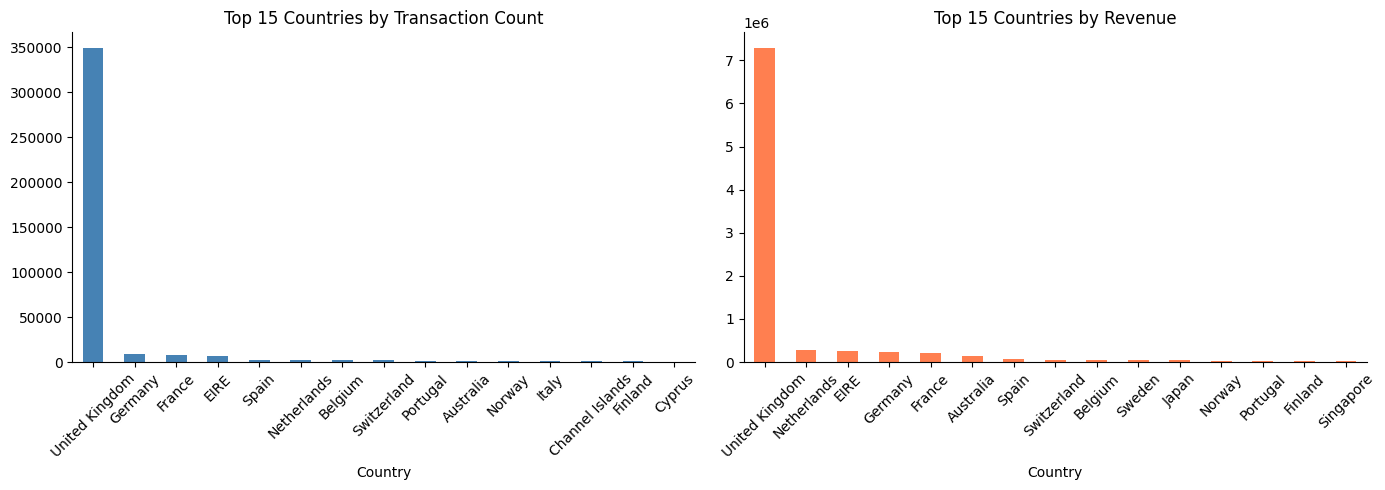

In [9]:
country_counts = df['Country'].value_counts().head(15)
country_revenue = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
country_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Countries by Transaction Count')
axes[0].tick_params(axis='x', rotation=45)
country_revenue.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Top 15 Countries by Revenue')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()

plt.show()


Top Countries by Transaction Count & Revenue (Cell 4a)

Helps: Identifies geographic market concentration and revenue sources

Inferences: Shows which countries drive business; highlights expansion opportunities; reveals if market is concentrated in few regions

### 4b. Top Products by Revenue


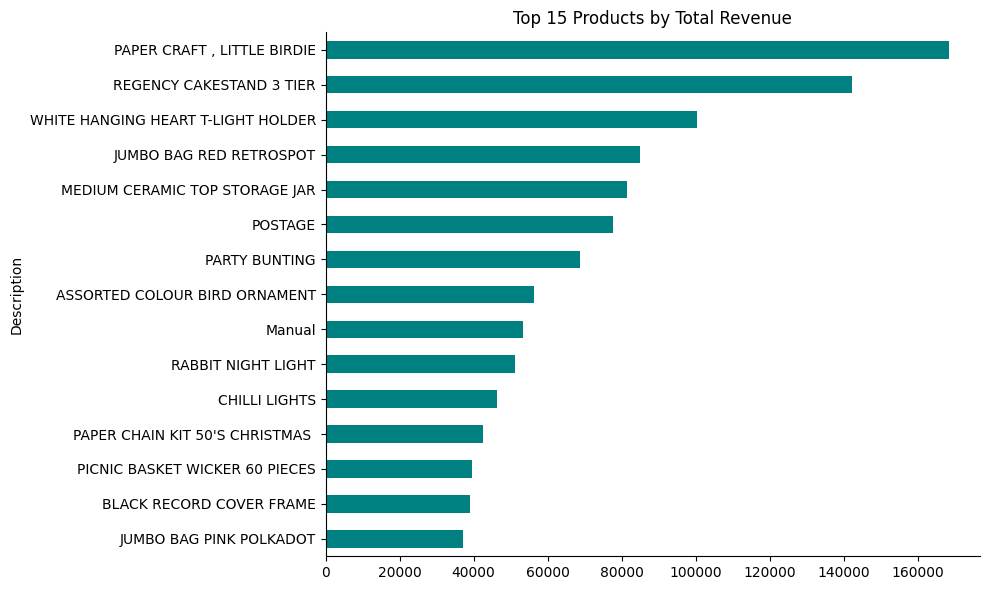

In [10]:
top_products_rev = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(10, 6))
top_products_rev.plot(kind='barh', ax=ax, color='teal')
ax.set_title('Top 15 Products by Total Revenue')
ax.invert_yaxis()
plt.tight_layout()

plt.show()


Top Products by Revenue 

Helps: Identifies best-performing SKUs and revenue drivers

Inferences: Reveals which products generate highest profit; guides inventory management; identifies cross-sell opportunities

### 4c. Monthly Revenue Trend


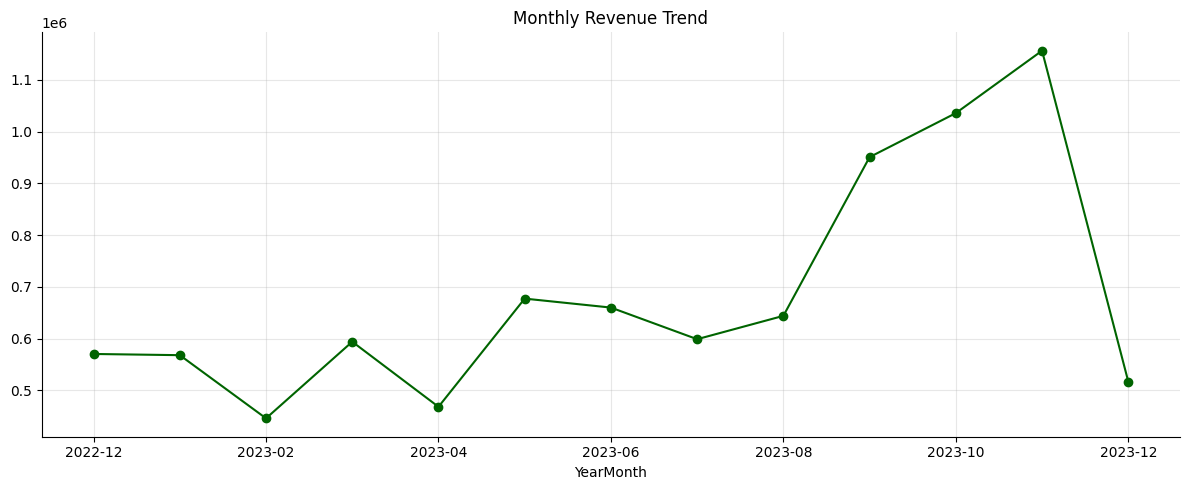

In [11]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)
monthly_revenue = df.groupby('YearMonth')['TotalPrice'].sum()
fig, ax = plt.subplots(figsize=(12, 5))
monthly_revenue.plot(kind='line', marker='o', ax=ax, color='darkgreen')
ax.set_title('Monthly Revenue Trend')
ax.grid(alpha=0.3)
plt.tight_layout()

plt.show()


Monthly Revenue Trend 

Helps: Detects seasonality, growth patterns, and business cycles

Inferences: Shows peak/off-peak seasons; reveals business health trend; enables demand forecasting for inventory planning

### 4d. Customer Spend Distribution


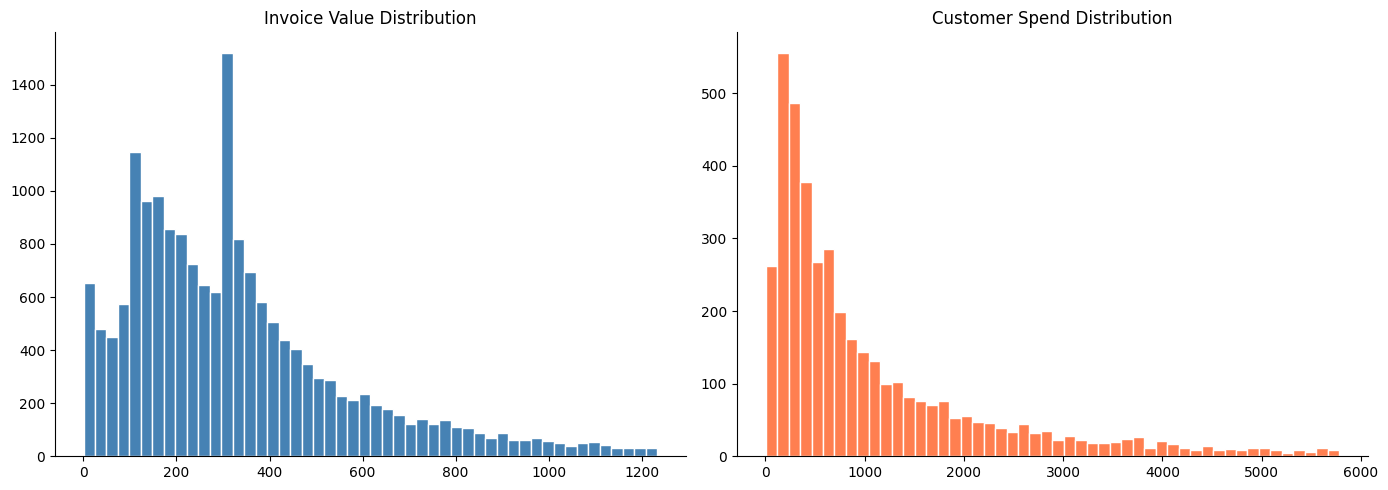

In [12]:
invoice_totals = df.groupby('InvoiceNo')['TotalPrice'].sum()
customer_spend = df.groupby('CustomerID')['TotalPrice'].sum()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cap_inv = invoice_totals.quantile(0.95)
axes[0].hist(invoice_totals[invoice_totals <= cap_inv], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Invoice Value Distribution')
cap_cust = customer_spend.quantile(0.95)
axes[1].hist(customer_spend[customer_spend <= cap_cust], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Customer Spend Distribution')
plt.tight_layout()

plt.show()


Invoice & Customer Spend Distribution 

Helps: Reveals customer value distribution (right-skewed pattern)

Inferences: Confirms Pareto principle (80/20 rule); shows most customers are low-value; justifies VIP program focus on top spenders

## Step 5 — RFM Feature Engineering

| Feature | Definition | Business Meaning |
|---------|-----------|------------------|
| **Recency** | Days since last purchase | Lower = more engaged |
| **Frequency** | Unique invoice count | Higher = more loyal |
| **Monetary** | Total spend | Higher = more valuable |


In [13]:
SNAPSHOT_DATE = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'RFM snapshot date: {SNAPSHOT_DATE.date()}')

rfm = (
    df.groupby('CustomerID')
    .agg(
        Recency   = ('InvoiceDate', lambda x: (SNAPSHOT_DATE - x.max()).days),
        Frequency = ('InvoiceNo',    'nunique'),
        Monetary  = ('TotalPrice',   'sum'),
    )
    .reset_index()
)
rfm['Monetary'] = rfm['Monetary'].round(2)
print(f'RFM table shape: {rfm.shape}')
rfm.head(10)


RFM snapshot date: 2023-12-10
RFM table shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


In [14]:
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))


       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2048.69
std     100.01       7.70    8985.23
min       1.00       1.00       3.75
25%      18.00       1.00     306.48
50%      51.00       2.00     668.57
75%     142.00       5.00    1660.60
max     374.00     209.00  280206.02


### 5a. RFM Distributions


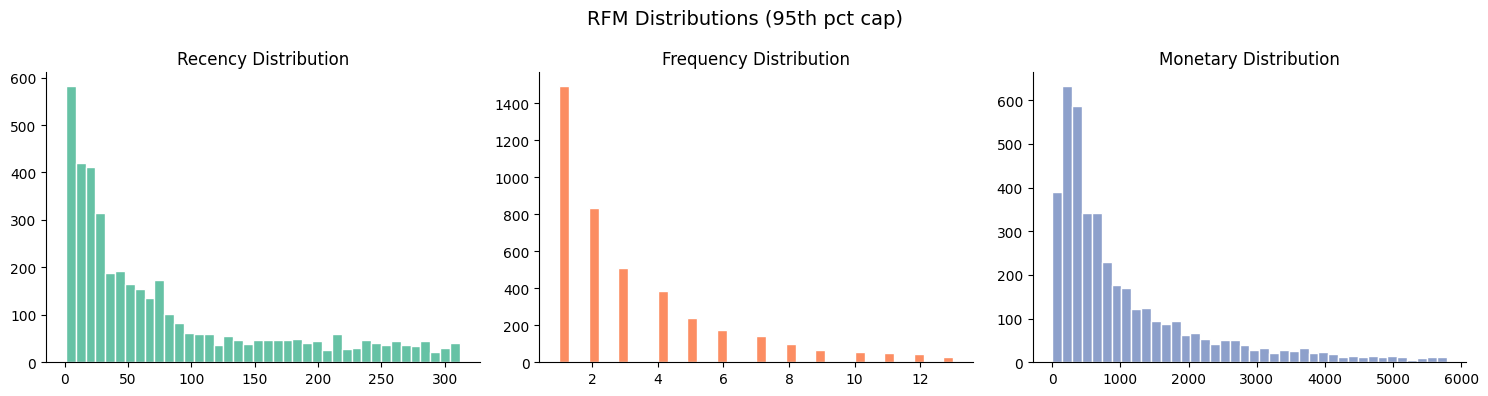

In [15]:
metrics = ['Recency', 'Frequency', 'Monetary']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, metric in enumerate(metrics):
    cap = rfm[metric].quantile(0.95)
    data = rfm[rfm[metric] <= cap][metric]
    axes[i].hist(data, bins=40, color=sns.color_palette('Set2')[i], edgecolor='white')
    axes[i].set_title(f'{metric} Distribution')
plt.suptitle('RFM Distributions (95th pct cap)', fontsize=14)
plt.tight_layout()
plt.show()


RFM Distributions 

Helps: Validates RFM dimensions are appropriate for clustering

Inferences:
Recency: Identifies recent vs. inactive customers
Frequency: Shows which customers are loyal repeaters
Monetary: Reveals lifetime value concentration

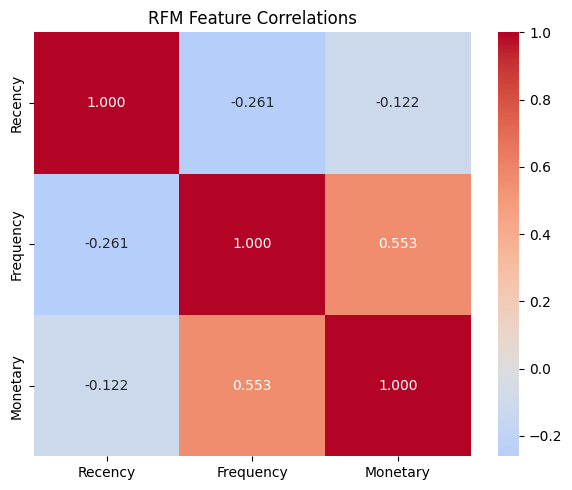

In [16]:
corr = rfm[['Recency', 'Frequency', 'Monetary']].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f', ax=ax)
ax.set_title('RFM Feature Correlations')
plt.tight_layout()

plt.show()


 RFM Correlation Heatmap 

Helps: Validates that all 3 RFM dimensions are necessary and complementary

Inferences: Strong correlations between dimensions confirm they work together for customer segmentation; validates the clustering approach

## Step 6 — Export Data for Clustering Model

Run `python train_spectrum_model.py` next, then `streamlit run app.py`.


In [17]:
from pathlib import Path

# Ensure we have the correct data directory path
BASE_DIR = Path('.').resolve()
DATA_DIR = BASE_DIR / 'data'
DATA_DIR.mkdir(parents=True, exist_ok=True)

customer_product_matrix = (
    df.groupby(['CustomerID', 'Description'])['Quantity']
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

df.to_csv(DATA_DIR / 'online_retail_cleaned.csv', index=False)
rfm.to_csv(DATA_DIR / 'rfm_features.csv', index=False)
customer_product_matrix.to_csv(DATA_DIR / 'customer_product_matrix.csv', index=False)

print('Saved:')
print('  data/online_retail_cleaned.csv')
print('  data/rfm_features.csv')
print('  data/customer_product_matrix.csv')

Saved:
  data/online_retail_cleaned.csv
  data/rfm_features.csv
  data/customer_product_matrix.csv
